# Venezuela 2026 — this study vs USGS NEIC finite-fault model

Side-by-side comparison of our combined WISP inversion (**ffm.4**, notebook 07) with the published
**USGS NEIC** finite-fault model (files in `USGS/`). Both are independent inversions; comparing them
tests how robust the rupture picture is.

**Important — what data each used.** Reading the USGS `complete_inversion.fsp` header, their model
inverted **teleseismic body (58) + surface (63) waves only** (`IMAGERY = 0`). So — despite the InSAR
products USGS distributes (`resampled_interferograms.zip`, `surface_deformation.disp`) — **their
published FFM did *not* invert InSAR**; it used the same data types as ours (body 59 + surf 61). The
InSAR is provided as a separate product (for surface-deformation / Coulomb), and adding it to the
*inversion* is exactly our planned next project. Both inversions also use the same WISP/Ji
wavelet-domain method and the same LITHO1.0-based velocity model, so this is close to an
apples-to-apples comparison — differences come mainly from **fault parameterization** (our single
planar segment vs USGS's two segments) and regularization.

In [1]:
import os, sys, json
import numpy as np, pandas as pd
from IPython.display import Image, display
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'scripts'))
import usgs_compare as uc

RUN = os.path.join(ROOT, 'results', 'ffm.4', 'NP1.big')
USGS = os.path.join(ROOT, 'data', 'usgs')
me = uc.parse_solution(os.path.join(RUN, 'Solution.txt'))
us = uc.parse_fsp(os.path.join(USGS, 'complete_inversion.fsp'))
print('parsed: this study %d subfaults | USGS %d subfaults' % (len(me['slip']), len(us['slip'])))
print('USGS header: Mw=%.3f  Mo=%.3e  avVr=%.2f km/s  avTr=%.1f s'
      % (us['Mw'], us['Mo'], us['avVr'], us['avTr']))

parsed: this study 168 subfaults | USGS 130 subfaults
USGS header: Mw=7.539  Mo=2.563e+20  avVr=2.32 km/s  avTr=9.9 s


## A. Source-parameter comparison

In [2]:
tm, mm = uc.parse_mr(os.path.join(RUN, 'STF.txt'))
tu, muu = uc.parse_mr(os.path.join(USGS, 'moment_rate.mr'))
Mo_me = np.trapz(mm, tm)
def dur(t, m): return float(t[m > 0.02*m.max()].max())
cmp = pd.DataFrame({
  'Quantity': ['Method / data', 'Fault parameterization', 'Mw', 'M0 (Nm)', 'Peak slip (m)',
               'Mechanism (strike/dip/rake)', 'Hypocentre depth (km)', 'Avg rupture velocity (km/s)',
               'Avg rise time (s)', 'Source duration (s)', 'Peak moment-rate time (s)'],
  'This study (ffm.4)': ['WISP, body 59 + surf 61', '1 segment, 28x6 = 168 subfaults', '7.57',
               '%.2e' % Mo_me, '%.2f' % me['slip'].max(), '86 / 74 / -176', '20.3',
               '~2.7 (slip-weighted)', '~10 (rise+fall median)', '~%.0f' % dur(tm, mm),
               '%.0f' % tm[mm.argmax()]],
  'USGS NEIC': ['WISP, body 58 + surf 63 (no InSAR)', '2 segments, 130 subfaults', '%.2f' % us['Mw'],
               '%.2e' % us['Mo'], '%.2f' % us['slip'].max(), '80 & 86 / 75 / -175', '20.0',
               '%.2f' % us['avVr'], '%.1f' % us['avTr'], '~%.0f' % dur(tu, muu),
               '%.0f' % tu[muu.argmax()]]})
display(cmp)

,Quantity,This study (ffm.4),USGS NEIC
0,Method / data,"WISP, body 59 + surf 61","WISP, body 58 + surf 63 (no InSAR)"
1,Fault parameterization,"1 segment, 28x6 = 168 subfaults","2 segments, 130 subfaults"
2,Mw,7.57,7.54
3,M0 (Nm),2.83e+20,2.56e+20
4,Peak slip (m),2.75,2.01
5,Mechanism (strike/dip/rake),86 / 74 / -176,80 & 86 / 75 / -175
6,Hypocentre depth (km),20.3,20.0
7,Avg rupture velocity (km/s),~2.7 (slip-weighted),2.32
8,Avg rise time (s),~10 (rise+fall median),9.9
9,Source duration (s),~115,~94


The headline numbers agree closely: **Mw 7.57 vs 7.54**, peak-slip ~2.8 vs ~2.5 m, subshear
rupture, same mechanism (E–W right-lateral strike-slip), same hypocentre depth, and an almost
identical peak moment-rate time (~40 s).

## B. Moment-rate function — the strongest agreement

Two independent inversions should agree most robustly on the moment-rate function (it is well
constrained by long-period data and integrates out fine spatial detail).

STF: mine dur~115s peak@40s | USGS dur~94s peak@40s -> results/ffm.4/NP1.big/plots/Compare_STF.png


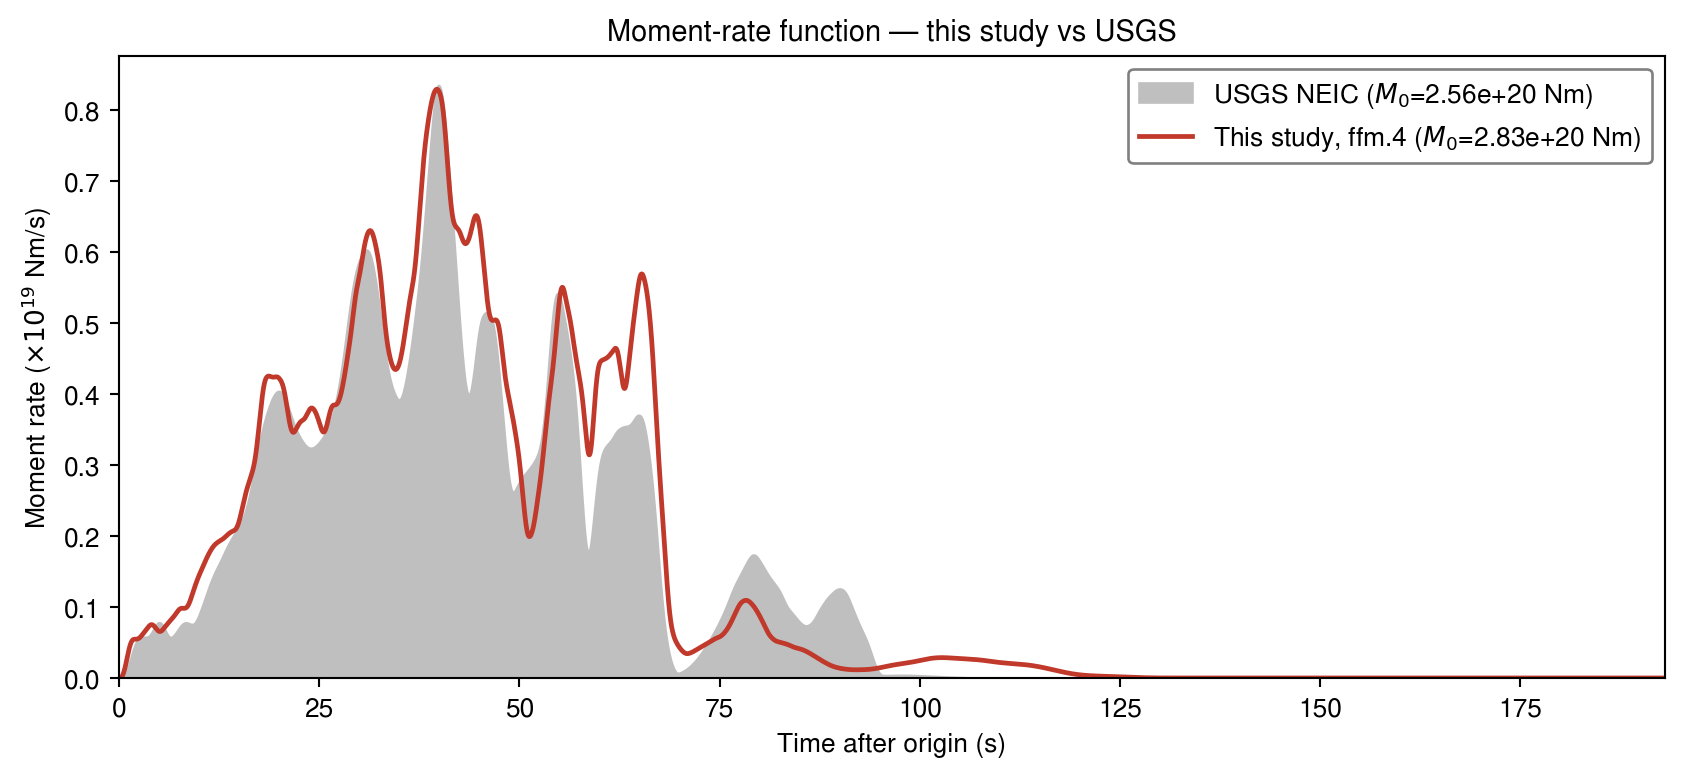

In [3]:
display(Image(uc.plot_stf(RUN, USGS)))

**Strikingly similar.** Both rise to a dominant pulse at **~40 s** of the same amplitude
(~0.8×10¹⁹ Nm/s), with matching secondary pulses near ~30, ~55, and ~65 s and a sharp drop after
~70 s. The total moments match (M₀ 2.83 vs 2.56×10²⁰; Mw 7.57 vs 7.54). Our STF carries a slightly
longer low-amplitude tail (to ~115 s vs ~95 s) — the eastern rupture is weakly constrained by the
70 s body-wave window (notebook 07, §B2) and supported mainly by surface waves. This near-identical
STF, from an independent inversion, is strong validation of the rupture's overall time history.

## C. Slip distribution — map view (their 2 segments vs our 1)

slip map -> results/ffm.4/NP1.big/plots/Compare_slip_map.png


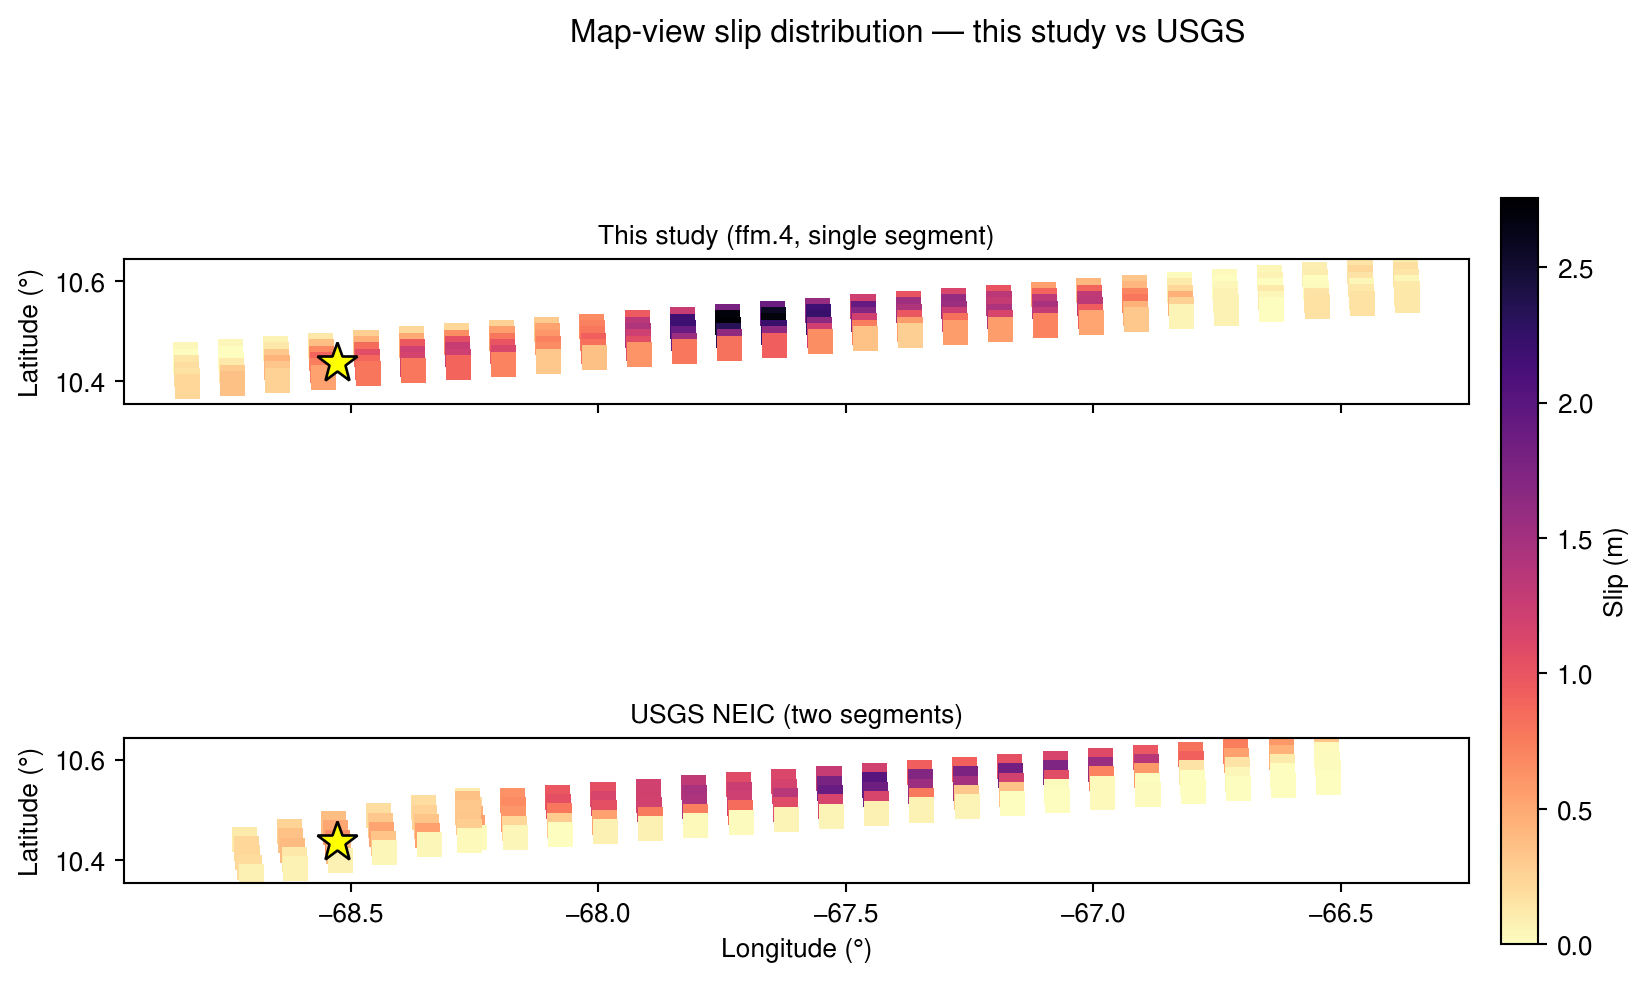

In [4]:
display(Image(uc.plot_slip_map(RUN, USGS)))

Both place the **main slip patch in the same longitude band (~−67.8° to −67.2°)**, ~70–120 km
east of the epicentre (star), offshore toward Caracas/La Guaira, with peak slip ~2–2.8 m. The USGS
model's slight along-strike bend is the join between its two segments (strike 80° → 86°); ours is a
single planar segment at strike 86°. Both taper to near-zero by ~−66.5°.

### Along-strike slip profile (dip-averaged)

slip profile -> results/ffm.4/NP1.big/plots/Compare_slip_profile.png


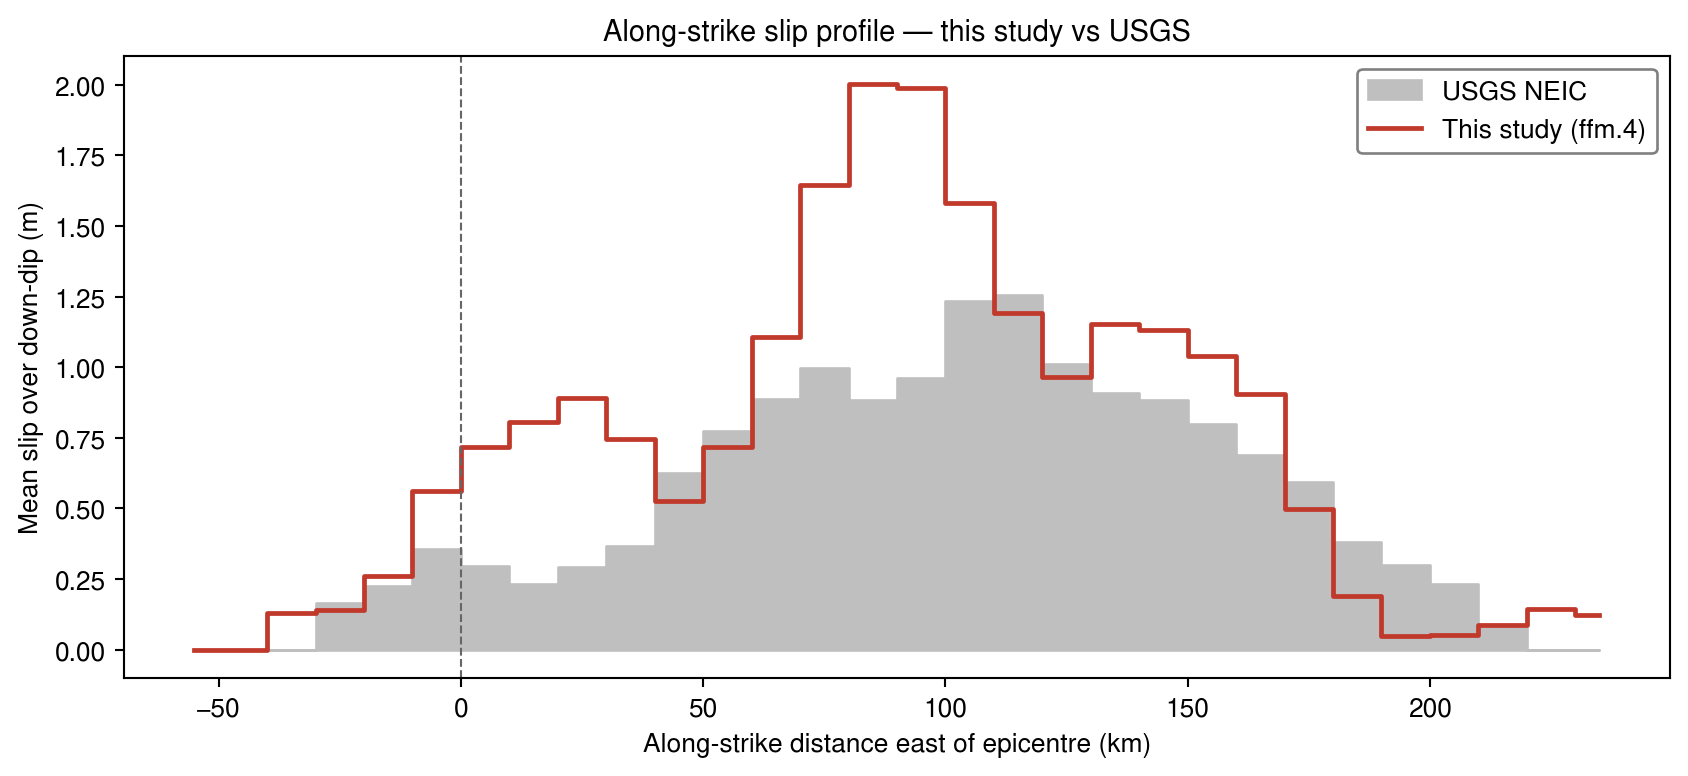

In [5]:
display(Image(uc.plot_slip_profile(RUN, USGS)))

The along-strike *distribution* agrees: main slip **70–170 km east**, tapering by ~200 km, with
minor slip west of the hypocentre. Differences: our profile is **more peaked** (concentrated near
~85 km) while the USGS profile is **broader and smoother** (peak ~105 km) — a typical consequence of
different smoothing/segmentation. *Caveat:* the vertical axis is mean slip averaged over the down-dip
direction, and USGS uses more down-dip rows (with more low-slip deep cells) than we do, so the
**absolute mean amplitudes are not directly comparable** — the robust comparison is the *shape and
extent*, which match. (Peak single-subfault slip is compared in the table above.)

## D. InSAR — what USGS provides, and our next step

USGS distributes coseismic InSAR products (`resampled_interferograms.zip` — downsampled LOS
displacement; `surface_deformation.disp`) and a Coulomb input (`coulomb.inp`), but — as noted above —
their **published FFM did not invert the InSAR** (`IMAGERY = 0`). WISP *can* invert InSAR
(`-t im`, with line-of-sight displacement points and a ramp term), so the natural enhancement, and our
**next project**, is to add the Sentinel-1 coseismic interferograms to this teleseismic inversion. That
would (i) pin the shallow slip and surface trace far better than teleseismic data alone, (ii) test the
single- vs two-segment geometry geodetically, and (iii) provide the coseismic baseline for the
postseismic afterslip / aftershock-deficit study that motivates the whole project.

## E. Take-homes

- **Independent corroboration.** Our combined WISP model and the USGS NEIC model agree on Mw
  (7.57 vs 7.54), mechanism (E–W right-lateral strike-slip), unilateral eastward directivity, subshear
  rupture, peak slip (~2.5–2.8 m), and the main slip location (~70–120 km east, offshore).
- **The moment-rate functions are nearly identical** — same ~40 s dominant pulse and multi-pulse
  shape — the strongest validation, from two independent inversions.
- **Slip distribution agrees in location and extent**; ours is more peaked, USGS broader/longer
  (230 km, 2 segments vs our ~160 km imaged on 1 segment) — differences attributable to
  parameterization and regularization, not to a different rupture.
- **Neither FFM used InSAR.** Adding Sentinel-1 InSAR to the inversion is the planned next step and
  the bridge to the afterslip / aftershock-deficit analysis.